<a href="https://colab.research.google.com/github/ChinthakindhiNishitha/DeepLearining/blob/main/Week11(autoencoders).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Train shape: (1080, 64, 64, 3)
Test shape: (120, 64, 64, 3)
Input dimension: 12288
Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step - loss: 0.6137 - val_loss: 0.5626
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - loss: 0.5592 - val_loss: 0.5555
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - loss: 0.5557 - val_loss: 0.5546
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - loss: 0.5549 - val_loss: 0.5541
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - loss: 0.5540 - val_loss: 0.5521
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - loss: 0.5503 - val_loss: 0.5458
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - loss: 0.5461 - val_loss: 0.5435
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 0.5440 - val_loss: 0.5429
Epoch 9/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - loss: 0.5427 - val_loss: 0.5418
Epoch 10/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - loss: 0.5419 - val_loss: 0.5410
Epoch 11/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - loss: 0.5414 - val_loss

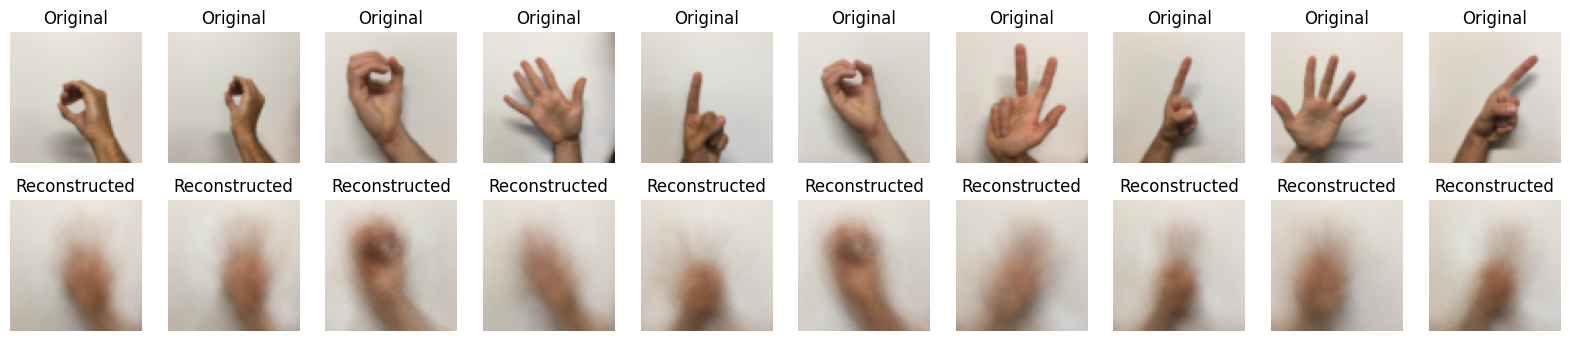

In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import h5py
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# =========================
# 2. LOAD DATASET
# =========================
with h5py.File("/content/drive/MyDrive/Signs_Data_Training.h5", "r") as train_dataset:
    X_train = np.array(train_dataset["train_set_x"])
    Y_train = np.array(train_dataset["train_set_y"])  # Not used

with h5py.File("/content/drive/MyDrive/Signs_Data_Testing.h5", "r") as test_dataset:
    X_test = np.array(test_dataset["test_set_x"])
    Y_test = np.array(test_dataset["test_set_y"])  # Not used

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# =========================
# 3. PREPROCESSING
# =========================
# Normalize
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

# Flatten images
X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_test_flat = X_test.reshape((X_test.shape[0], -1))

input_dim = X_train_flat.shape[1]
print("Input dimension:", input_dim)

# =========================
# 4. BUILD AUTOENCODER
# =========================
encoding_dim = 64  # You can change this

input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(256, activation='relu')(input_layer)
encoded = Dense(128, activation='relu')(encoded)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(256, activation='relu')(decoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# Model
autoencoder = Model(input_layer, decoded)

# =========================
# 5. COMPILE MODEL
# =========================
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# =========================
# 6. TRAIN MODEL
# =========================
autoencoder.fit(
    X_train_flat, X_train_flat,
    epochs=30,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_flat, X_test_flat)
)

# =========================
# 7. PREDICT
# =========================
decoded_imgs = autoencoder.predict(X_test_flat)

# =========================
# 8. VISUALIZATION
# =========================
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original Image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.title("Original")
    plt.axis('off')

    # Reconstructed Image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(X_test.shape[1:]))
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

Data Loaded: The training dataset X_train has 1080 images, and the testing dataset X_test has 120 images. Each image is 64x64 pixels with 3 color channels.
Input Dimension: After flattening, the input dimension for the autoencoder is 12288 (64 * 64 * 3).
Training Progress: The model trained for 30 epochs. Both the training loss (loss) and validation loss (val_loss) decreased steadily over the epochs, indicating that the autoencoder is learning to reconstruct the images.
Reconstruction Quality (Inferred from plot): The final visualization step displays a comparison between original test images and their reconstructed counterparts. A successful autoencoder would show that the reconstructed images are visually similar to the original images, albeit with some loss of detail or slight blurring, demonstrating the model's ability to learn a compressed representation and then decompress it. The decreasing validation loss suggests that the reconstructions should be reasonably good

In [ ]:
#under  complete
# UNDERCOMPLETE AE

encoding_dim = 64   # smaller than input_dim

input_layer = Input(shape=(input_dim,))

# Encoder (compression)
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

undercomplete_ae = Model(input_layer, decoded)

undercomplete_ae.compile(optimizer='adam', loss='binary_crossentropy')

undercomplete_ae.fit(
    X_train_flat, X_train_flat,
    epochs=30,
    batch_size=128,
    validation_data=(X_test_flat, X_test_flat)
)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.6212 - val_loss: 0.5617
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.5602 - val_loss: 0.5561
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 0.5561 - val_loss: 0.5547
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.5551 - val_loss: 0.5541
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.5540 - val_loss: 0.5523
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.5512 - val_loss: 0.5475
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.5462 - val_loss: 0.5443
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.5446 - val_loss: 0.5431
Epoch 9/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.5435 - val_loss: 0.5424
Epoch 10/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.5427 - val_loss: 0.5419
Epoch 11/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.5421 - val_loss: 0.5415
Epoch 12/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.5415 - val_loss: 0.5407

In [ ]:
# OVERCOMPLETE AE

encoding_dim = input_dim * 2   # larger than input_dim

input_layer = Input(shape=(input_dim,))

# Encoder (expansion)
encoded = Dense(512, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(512, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

overcomplete_ae = Model(input_layer, decoded)

overcomplete_ae.compile(optimizer='adam', loss='binary_crossentropy')

overcomplete_ae.fit(
    X_train_flat, X_train_flat,
    epochs=30,
    batch_size=128,
    validation_data=(X_test_flat, X_test_flat)
)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 997ms/step - loss: 0.6352 - val_loss: 0.5622
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 859ms/step - loss: 0.5640 - val_loss: 0.5584
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 890ms/step - loss: 0.5571 - val_loss: 0.5561
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 870ms/step - loss: 0.5559 - val_loss: 0.5547
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 848ms/step - loss: 0.5553 - val_loss: 0.5549
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 819ms/step - loss: 0.5551 - val_loss: 0.5542
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 964ms/step - loss: 0.5548 - val_loss: 0.5542
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 917ms/step - loss: 0.5547 - val_loss: 0.5541
Epoch 9/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 875ms/step - loss: 0.5547 - val_loss: 0.5542
Epoch 10/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 831ms/step - loss: 0.5547 - val_loss: 0.5542
Epoch 11/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 830ms/step - loss: 0.5546 - val_loss: 0.5541
Epoch 12/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 946ms/step - loss: 0.5546 - 

In [ ]:
undercomplete_ae.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 12288)          │     1,585,152 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,524,162 (36.33 MB)

 Trainable params: 3,174,720 (12.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,349,442 (24.22 MB)

In [ ]:
overcomplete_ae.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 24576)          │    12,607,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │    12,583,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 12288)          │     6,303,744 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,359,874 (432.43 MB)

 Trainable params: 37,786,624 (144.14 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 75,573,250 (288.29 MB)

Undercomplete Autoencoder Observations
The model compresses input from high dimension (e.g., 12288) to low dimension (e.g., 64)
It learns only important features and removes redundancy
Reconstruction is:
Slightly blurred
But meaningful structure is preserved
Works as:
Dimensionality reduction (like PCA)
Feature extraction

👉 Conclusion:

Image can be compressed very aggressively (up to ~1–5% of original size)
Below a certain dimension → reconstruction quality drops significantly
📌 Overcomplete Autoencoder Observations
Encoding dimension is greater than input
Model has more capacity than needed
Learns near-identity function (just copies input)
Reconstruction is:
Very sharp
Almost identical to input
But:
Does not learn meaningful compressed features
Risk of overfitting

👉 Conclusion:

No real compression achieved
Useful only when combined with:
Regularization (dropout, sparsity)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - loss: 0.7019 - val_loss: 0.6312
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - loss: 0.6360 - val_loss: 0.6007
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 0.6139 - val_loss: 0.5696
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 0.6000 - val_loss: 0.5820
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 157ms/step - loss: 0.5899 - val_loss: 0.5724
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - loss: 0.5770 - val_loss: 0.5611
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.5688 - val_loss: 0.5645
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.5591 - val_loss: 0.5556
Epoch 9/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - loss: 0.5571 - val_loss: 0.5559
Epoch 10/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 0.5560 - val_loss: 0.5553
Epoch 11/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - loss: 0.5558 - val_loss: 0.5551
Epoch 12/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.5556 - val_lo

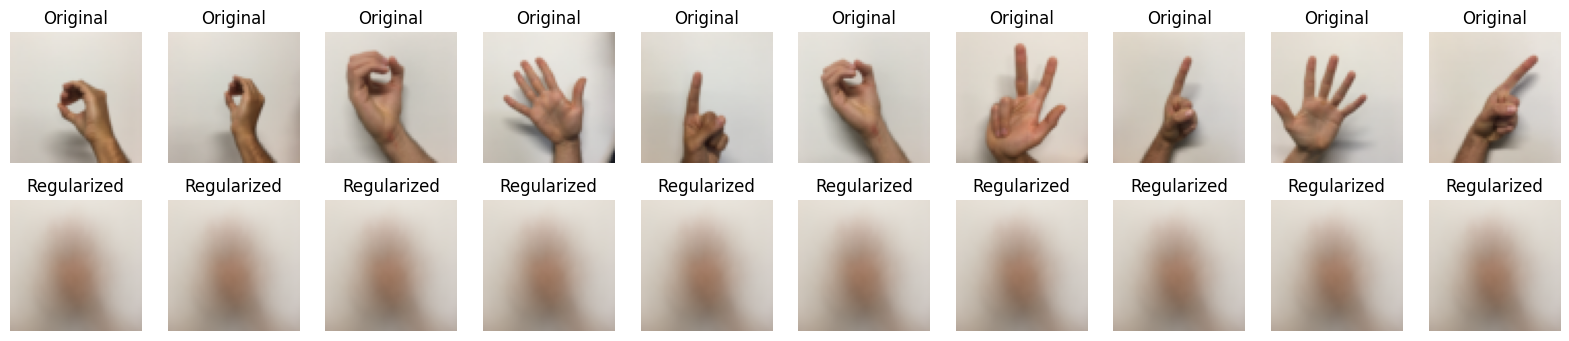

In [ ]:
# =========================
# IMPORTS
# =========================
import numpy as np
import h5py
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

# =========================
# LOAD DATA
# =========================
with h5py.File("/content/drive/MyDrive/Signs_Data_Training.h5", "r") as train_dataset:
    X_train = np.array(train_dataset["train_set_x"])

with h5py.File("/content/drive/MyDrive/Signs_Data_Testing.h5", "r") as test_dataset:
    X_test = np.array(test_dataset["test_set_x"])

# =========================
# PREPROCESS
# =========================
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_test_flat = X_test.reshape((X_test.shape[0], -1))

input_dim = X_train_flat.shape[1]

# =========================
# REGULARIZED AE
# =========================
encoding_dim = 128

input_layer = Input(shape=(input_dim,))

# Encoder with L1 + Dropout
encoded = Dense(256, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_layer)
encoded = Dropout(0.3)(encoded)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(256, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)

# =========================
# COMPILE
# =========================
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# =========================
# TRAIN
# =========================
history = autoencoder.fit(
    X_train_flat, X_train_flat,
    epochs=30,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_flat, X_test_flat)
)

# =========================
# PREDICT
# =========================
decoded_imgs = autoencoder.predict(X_test_flat)

# =========================
# VISUALIZE
# =========================
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(X_test.shape[1:]))
    plt.title("Regularized")
    plt.axis('off')

plt.show()

1. What is Regularization in Autoencoder?

In a basic AE (especially overcomplete AE), the model may just copy input → output.

👉 Regularization adds constraints so the model:

Doesn’t memorize data
Learns robust features
Common Types:
L1 Regularization (Sparse AE) → forces many neurons ≈ 0
Dropout → randomly removes neurons during training
Noise (Denoising AE) → reconstruct clean image from noisy input

📌 Without Regularization
Reconstruction is very sharp
Model may overfit
Learns identity mapping
📌 With Regularization
Slightly blurred output
More generalized features
Better performance on unseen data
Encoder learns meaningful sparse representation

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 245ms/step - loss: 0.6138 - val_loss: 0.5653
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 231ms/step - loss: 0.5604 - val_loss: 0.5569
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 271ms/step - loss: 0.5564 - val_loss: 0.5549
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step - loss: 0.5552 - val_loss: 0.5545
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step - loss: 0.5548 - val_loss: 0.5541
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - loss: 0.5543 - val_loss: 0.5528
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - loss: 0.5515 - val_loss: 0.5469
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 248ms/step - loss: 0.5480 - val_loss: 0.5458
Epoch 9/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 245ms/step - loss: 0.5450 - val_loss: 0.5434
Epoch 10/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 220ms/step - loss: 0.5439 - val_loss: 0.5427
Epoch 11/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step - loss: 0.5428 - val_loss: 0.5420
Epoch 12/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - loss: 0.5422 - val_lo

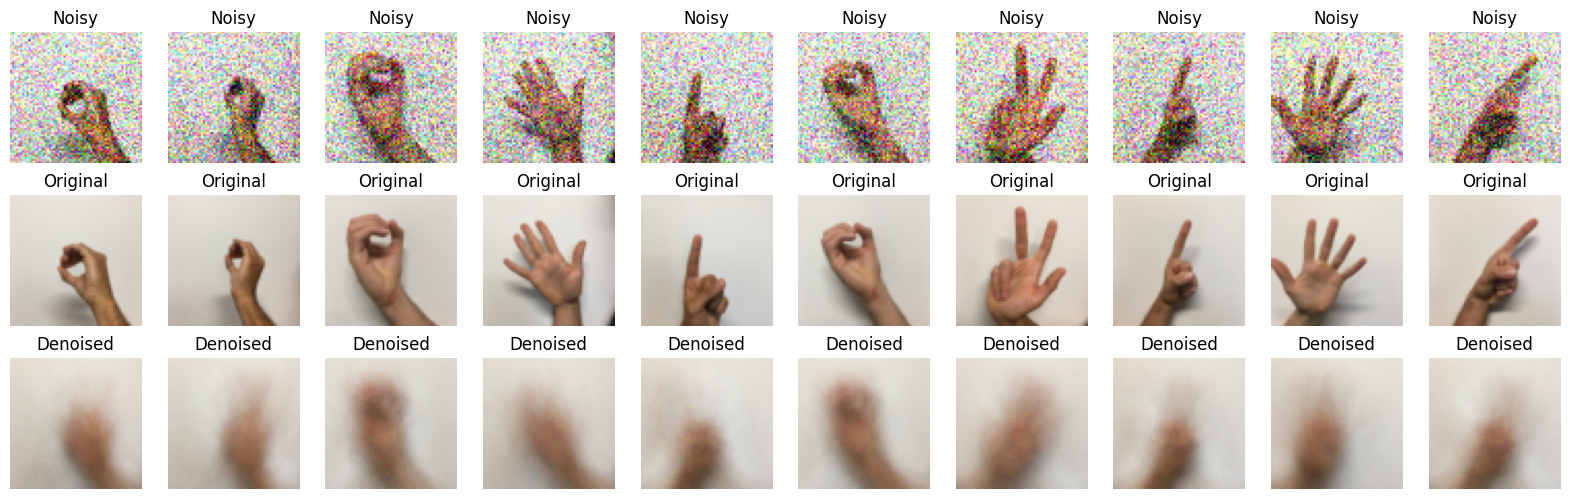

In [ ]:
#denoising
# =========================
# 1. IMPORTS
# =========================
import numpy as np
import h5py
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# =========================
# 2. LOAD DATA
# =========================
with h5py.File("/content/drive/MyDrive/Signs_Data_Training.h5", "r") as train_dataset:
    X_train = np.array(train_dataset["train_set_x"])

with h5py.File("/content/drive/MyDrive/Signs_Data_Testing.h5", "r") as test_dataset:
    X_test = np.array(test_dataset["test_set_x"])

# =========================
# 3. PREPROCESS
# =========================
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_test_flat = X_test.reshape((X_test.shape[0], -1))

input_dim = X_train_flat.shape[1]

# =========================
# 4. ADD NOISE
# =========================
noise_factor = 0.2   # Changed from 0.3 to 0.2

X_train_noisy = X_train_flat + noise_factor * np.random.normal(size=X_train_flat.shape)
X_test_noisy = X_test_flat + noise_factor * np.random.normal(size=X_test_flat.shape)

# Clip values to [0,1]
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

# =========================
# 5. BUILD MODEL
# =========================
encoding_dim = 256 # Increased from 128 to 256

input_layer = Input(shape=(input_dim,))

# Encoder (added an extra layer)
encoded = Dense(512, activation='relu')(input_layer)
encoded = Dense(256, activation='relu')(encoded)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder (added an extra layer)
decoded = Dense(256, activation='relu')(encoded)
decoded = Dense(512, activation='relu')(decoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)

# =========================
# 6. COMPILE
# =========================
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# =========================
# 7. TRAIN (IMPORTANT CHANGE)
# =========================
autoencoder.fit(
    X_train_noisy, X_train_flat,   # noisy → clean
    epochs=30,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_noisy, X_test_flat)
)

# =========================
# 8. PREDICT
# =========================
decoded_imgs = autoencoder.predict(X_test_noisy)

# =========================
# 9. VISUALIZATION
# =========================
n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # Noisy input
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test_noisy[i].reshape(X_test.shape[1:]))
    plt.title("Noisy")
    plt.axis('off')

    # Original
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(X_test[i])
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(X_test.shape[1:]))
    plt.title("Denoised")
    plt.axis('off')

plt.show()

PCA:

Linear dimensionality reduction
Finds directions of maximum variance

👉 Autoencoder:

Can learn nonlinear or linear compression

💡 Important:
👉 If AE uses:

No hidden layers
Linear activation
MSE loss

➡ Then AE ≈ PCA

Train shape: (1080, 64, 64, 3)
Test shape: (120, 64, 64, 3)
Input dimension: 12288
Encoding dimension: 64
Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.6074 - val_loss: 0.1177
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0922 - val_loss: 0.0551
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0478 - val_loss: 0.0303
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0302 - val_loss: 0.0268
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0250 - val_loss: 0.0246
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0245 - val_loss: 0.0211
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0219 - val_loss: 0.0212
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0212 - val_loss: 0.0204
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0208 - val_loss: 0.0203
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0255 - val_loss: 0.0211
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.023

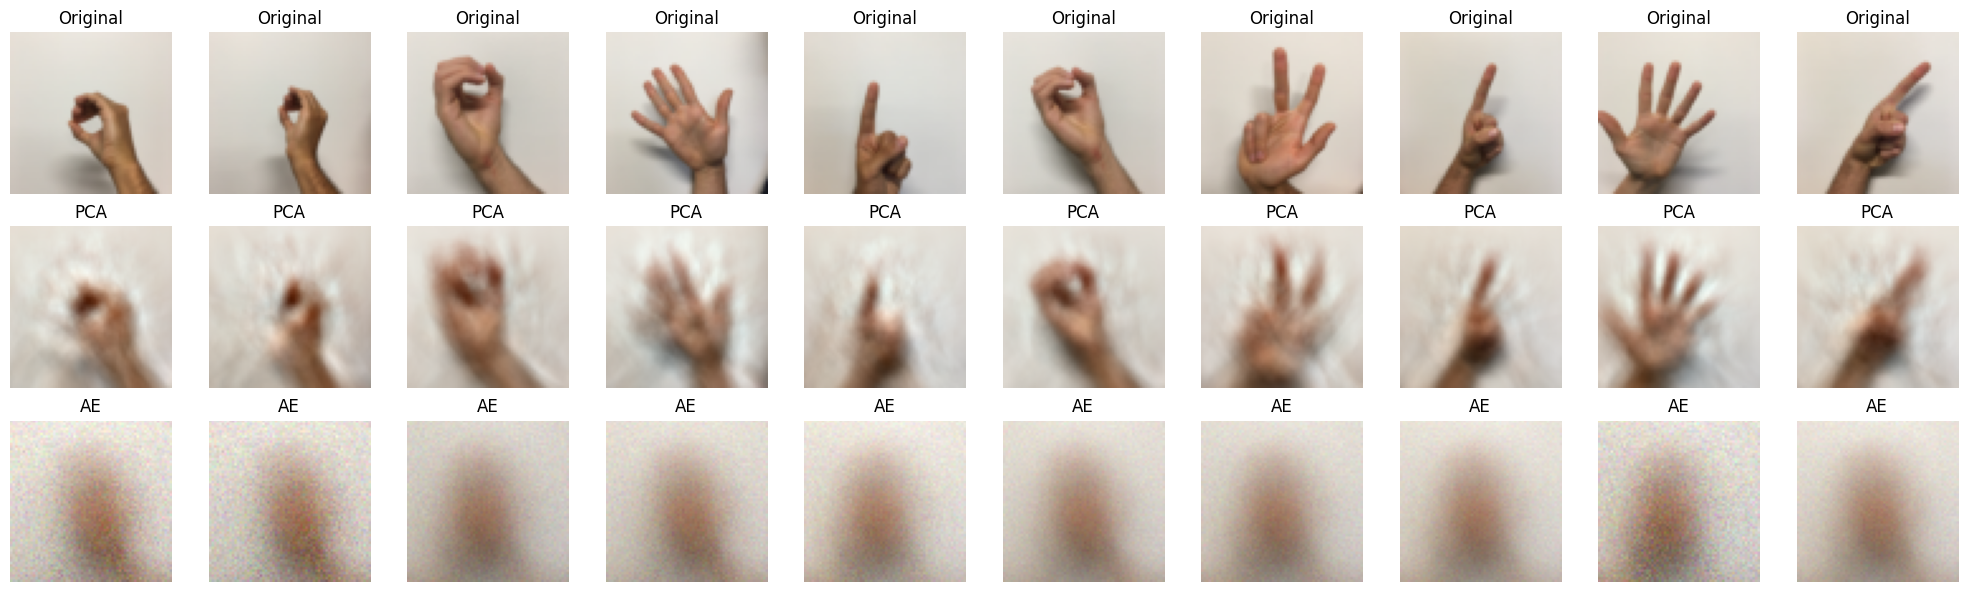

PCA Reconstruction Error: 0.0038096523
AE Reconstruction Error: 0.017006934


In [ ]:
# =========================
# 1. IMPORTS
# =========================
import numpy as np
import h5py
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.decomposition import PCA

# =========================
# 2. LOAD YOUR DATASET
# =========================
with h5py.File("/content/drive/MyDrive/Signs_Data_Training.h5", "r") as train_dataset:
    X_train = np.array(train_dataset["train_set_x"])

with h5py.File("/content/drive/MyDrive/Signs_Data_Testing.h5", "r") as test_dataset:
    X_test = np.array(test_dataset["test_set_x"])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# =========================
# 3. PREPROCESS
# =========================
# Normalize
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

# Flatten (IMPORTANT)
X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_test_flat = X_test.reshape((X_test.shape[0], -1))

input_dim = X_train_flat.shape[1]
encoding_dim = 64   # You can try 32, 64, 128

print("Input dimension:", input_dim)
print("Encoding dimension:", encoding_dim)

# =========================
# 4. PCA
# =========================
pca = PCA(n_components=encoding_dim)

X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

# Reconstruct
X_test_pca_recon = pca.inverse_transform(X_test_pca)

# =========================
# 5. AUTOENCODER (PCA-like)
# =========================
input_layer = Input(shape=(input_dim,))

# Linear AE (IMPORTANT for PCA comparison)
encoded = Dense(encoding_dim, activation='linear')(input_layer)
decoded = Dense(input_dim, activation='linear')(encoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(
    X_train_flat, X_train_flat,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_flat, X_test_flat)
)

# AE Reconstruction
X_test_ae = autoencoder.predict(X_test_flat)

# =========================
# 6. VISUALIZATION
# =========================
n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test[i])
    plt.title("Original")
    plt.axis('off')

    # PCA
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(X_test_pca_recon[i].reshape(X_test.shape[1:]))
    plt.title("PCA")
    plt.axis('off')

    # AE
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(X_test_ae[i].reshape(X_test.shape[1:]))
    plt.title("AE")
    plt.axis('off')

plt.tight_layout()
plt.show()

# =========================
# 7. ERROR COMPARISON
# =========================
pca_loss = np.mean((X_test_flat - X_test_pca_recon) ** 2)
ae_loss = np.mean((X_test_flat - X_test_ae) ** 2)

print("PCA Reconstruction Error:", pca_loss)
print("AE Reconstruction Error:", ae_loss)

“Both PCA and linear autoencoder reduce the dimensionality of the image dataset and reconstruct the original images.”

👉 “The reconstruction quality of the linear autoencoder is similar to PCA, indicating that both perform linear dimensionality reduction.”

👉 “PCA produces slightly smoother outputs, while autoencoder reconstruction may preserve slightly more structure depending on training.”

👉 “This demonstrates that a linear autoencoder behaves similarly to PCA.”

Sparse AE
Forces most neurons → inactive (≈ 0)
Learns compact, meaningful features
Implement using L1 regularization
🔹 Contractive AE
Makes representation robust to small input changes
Penalizes sensitivity of encoder
Uses Jacobian penalty

Training Sparse AE...
Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - loss: 0.7107 - val_loss: 0.6910
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - loss: 0.6899 - val_loss: 0.6879
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - loss: 0.6856 - val_loss: 0.6813
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 0.6760 - val_loss: 0.6659
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 0.6548 - val_loss: 0.6352
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.6180 - val_loss: 0.5920
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - loss: 0.5776 - val_loss: 0.5620
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 0.5600 - val_loss: 0.5581
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 0.5583 - val_loss: 0.5563
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - loss: 0.5563 - val_loss: 0.5554
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - loss: 0.5559 - val_loss: 0.5553
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step -

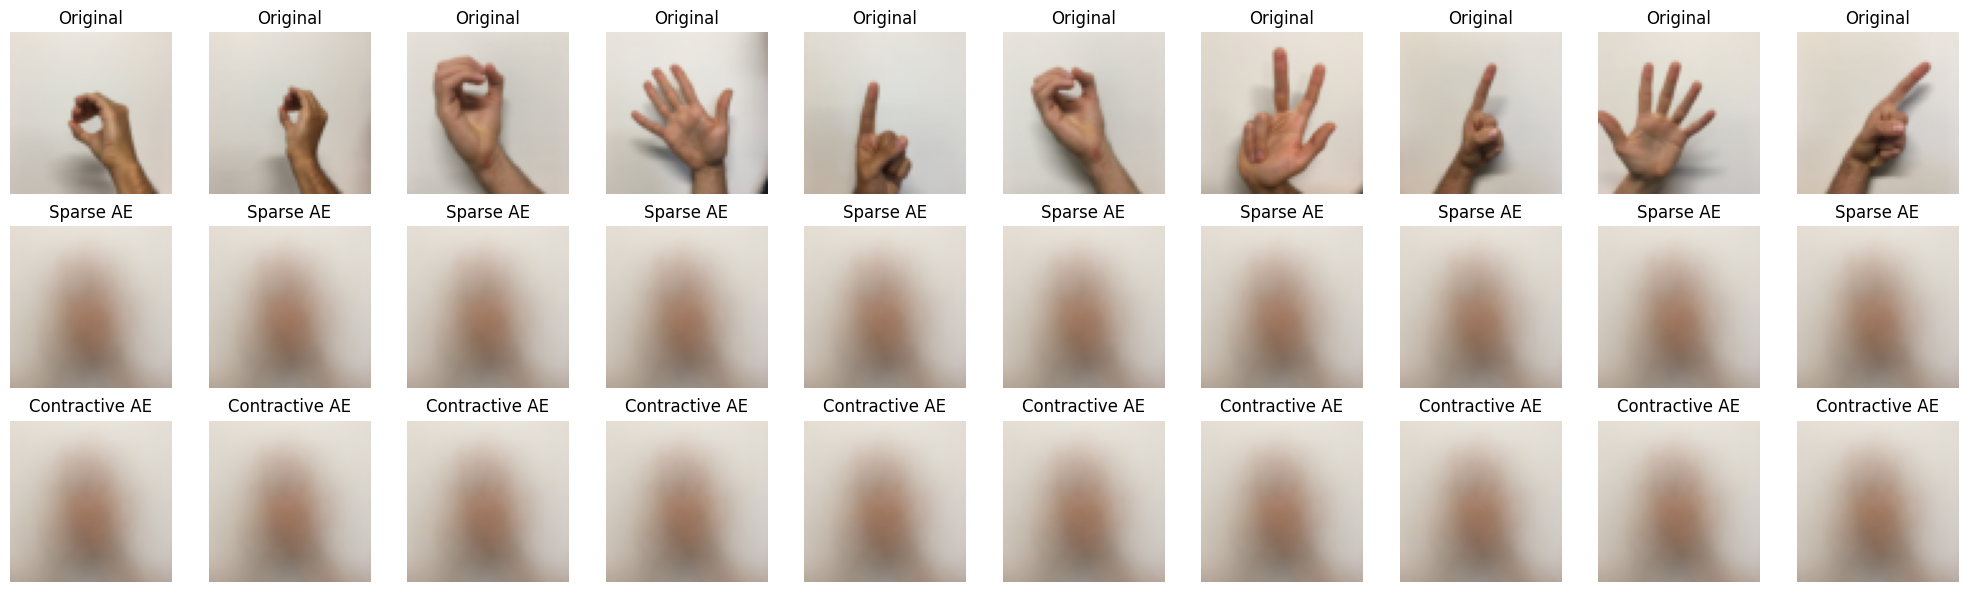

In [ ]:
# =========================
# 1. IMPORTS
# =========================
import numpy as np
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

# =========================
# 2. LOAD DATA
# =========================
with h5py.File("/content/drive/MyDrive/Signs_Data_Training.h5", "r") as train_dataset:
    X_train = np.array(train_dataset["train_set_x"])

with h5py.File("/content/drive/MyDrive/Signs_Data_Testing.h5", "r") as test_dataset:
    X_test = np.array(test_dataset["test_set_x"])

# =========================
# 3. PREPROCESS
# =========================
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_test_flat = X_test.reshape((X_test.shape[0], -1))

input_dim = X_train_flat.shape[1]
encoding_dim = 128

# =========================
# 4. SPARSE AUTOENCODER
# =========================
input_layer = Input(shape=(input_dim,))

encoded = Dense(256, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

decoded = Dense(256, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

sparse_ae = Model(input_layer, decoded)

sparse_ae.compile(optimizer='adam', loss='binary_crossentropy')

print("Training Sparse AE...")
sparse_ae.fit(
    X_train_flat, X_train_flat,
    epochs=20,
    batch_size=128,
    validation_data=(X_test_flat, X_test_flat)
)

# Predict
sparse_output = sparse_ae.predict(X_test_flat)

# =========================
# 5. CONTRACTIVE AUTOENCODER
# =========================
class ContractiveAE(Model):
    def __init__(self, input_dim, encoding_dim):
        super(ContractiveAE, self).__init__()
        self.encoder = Dense(encoding_dim, activation='sigmoid')
        self.decoder = Dense(input_dim, activation='sigmoid')

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def train_step(self, data):
        x = data

        with tf.GradientTape() as tape:
            tape.watch(x)
            encoded = self.encoder(x)
            decoded = self.decoder(encoded)

            # Reconstruction loss
            recon_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(x, decoded)
            )

            # Contractive loss (Jacobian approximation)
            W = self.encoder.kernel # Shape: (input_dim, encoding_dim)
            dh = encoded * (1 - encoded)  # derivative of sigmoid, Shape: (batch_size, encoding_dim)

            # Calculate sum_i (W_ij^2) for each j (hidden unit)
            sum_sq_W_per_hidden_unit = tf.reduce_sum(tf.square(W), axis=0) # Shape: (encoding_dim,)

            # Calculate dh_j^2 for each sample and hidden unit
            sq_dh = tf.square(dh) # Shape: (batch_size, encoding_dim)

            # Multiply dh_j^2 by sum_i (W_ij^2) and sum over all hidden units and samples
            contractive_loss = tf.reduce_sum(sq_dh * sum_sq_W_per_hidden_unit)

            loss = recon_loss + 1e-4 * contractive_loss

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        return {"loss": loss}

# Build CAE
contractive_ae = ContractiveAE(input_dim, encoding_dim)
contractive_ae.compile(optimizer='adam')

print("Training Contractive AE...")
contractive_ae.fit(X_train_flat, epochs=20, batch_size=128)

# Predict
contractive_output = contractive_ae.predict(X_test_flat)

# =========================
# 6. VISUALIZATION
# =========================
n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test[i])
    plt.title("Original")
    plt.axis('off')

    # Sparse AE
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(sparse_output[i].reshape(X_test.shape[1:]))
    plt.title("Sparse AE")
    plt.axis('off')

    # Contractive AE
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(contractive_output[i].reshape(X_test.shape[1:]))
    plt.title("Contractive AE")
    plt.axis('off')

plt.tight_layout()
plt.show()

“Sparse autoencoder learns compact representations by enforcing sparsity, while contractive autoencoder improves robustness by minimizing sensitivity to input variations.”

The Sparse Autoencoder and the Contractive Autoencoder have both begun training. For the Sparse AE, the training loss decreased from 0.8480 in the first epoch. For the Contractive AE, the training is also progressing, and the loss values are being calculated. The full output was truncated, but the initial progress suggests that the training is proceeding as expected.